# Lab 7: Conditionals and Iteration

Sometimes you don't want code to run, especially in a function. You can prevent code from running in a prespecified number of conditions by using conditional statements. Work hard on this unit, as it is essential for optimization and good coding hygiene. 

Please complete this lab by providing answers in cells after the question. Use **Code** cells to write and run any code you need to answer the question and **Markdown** cells to write out answers in words. After you are finished with the assignment, remember to download it as an **.html file** and submit it in **ELMS**.

In [ ]:
# These lines import the Numpy and Datascience modules.
import numpy as np
import datascience as ds

# These lines do some fancy plotting magic
import matplotlib
# Required to view plots in a notebook
%matplotlib inline
import matplotlib.pyplot as plt
# This is just to make the plots look a certain way
plt.style.use('fivethirtyeight')

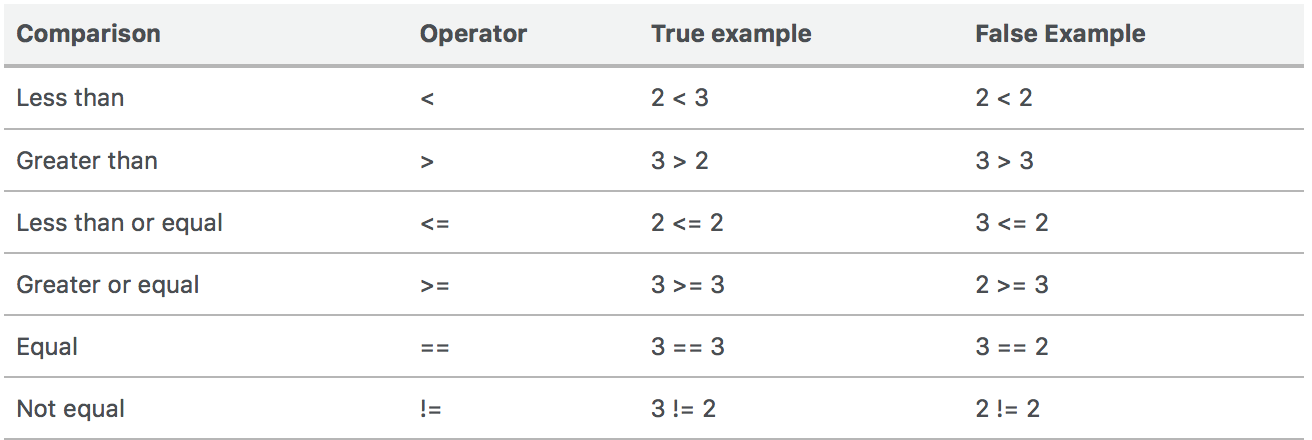## Conditionals

In Python, the boolean data type contains only two unique values:  `True` and `False`. Expressions containing comparison operators such as `<` (less than), `>` (greater than), and `==` (equal to) evaluate to Boolean values. A list of common comparison operators can be found below.

<img src="comparisons.png">

Run the cell below to see an example of a comparison operator in action.

In [ ]:
3 > 1 + 1

We can even assign the result of a comparison operation to a variable.

In [ ]:
result = 10 / 2 == 5
result

Arrays are compatible with comparison operators. The output is an array of boolean values.

In [ ]:
ds.make_array(1, 5, 7, 8, 3, -1) > 3

Consider a game of "Rock, Paper, Scissors" in which two players choose one of three options (rock, paper, or scissors) and the outcome of the game is decided by who chose what. Rock beats scissors, scissors beats paper, and paper beats rock. 

Let's try and simulate choosing an option at random using the function, `np.random.choice(...)`.

### `np.random.choice()`

`np.random.choice()` picks one item at random from the given array. It is equally likely to pick any of the items. Run the cell below several times, and observe how the results change.

In [ ]:
sign = ds.make_array('rock', 'paper', 'scissors')
np.random.choice(sign)

To repeat this process multiple times, pass in an int `n` as the second argument. By default, `np.random.choice()` samples **with replacement** and returns an *array* of items. That is, whenever the function samples from the array, it returns that item back to the array instead of removing. If we were to specify `replace = False`, then sampling multiple items from the array would not return any items back to array for each subsequent sample.

Run the next cell to see an example of sampling with replacement 10 times from the `sign` array.

In [ ]:
np.random.choice(sign, 10)

<font color = 'red'>**Question 1. Assume we played ten games, choosing signs at random, and stored the results in an array called `ten_signs` as done below. Find the number of times you chose rock using code (do not hardcode the answer).**</font>

*Hint:* Our solution involves a comparison operator (e.g. `=`, `<`, ...) and `np.count_nonzero` or `sum`.

In [ ]:
ten_signs = ...
number_rock = ...
number_rock

**Conditional Statements**

A conditional statement is a multi-line statement that allows Python to choose among different alternatives based on the truth value of an expression.

Here is a basic example.

```
def sign(x):
    if x > 0:
        return 'Positive'
    else:
        return 'Negative'
```

If the input `x` is greater than `0`, we return the string `'Positive'`. Otherwise, we return `'Negative'`.

If we want to test multiple conditions at once, we use the following general format.

```
if <if expression>:
    <if body>
elif <elif expression 0>:
    <elif body 0>
elif <elif expression 1>:
    <elif body 1>
...
else:
    <else body>
```

Only the body for the first conditional expression that is true will be evaluated. Each `if` and `elif` expression is evaluated and considered in order, starting at the top. As soon as a true value is found, the corresponding body is executed, and the rest of the conditional statement is skipped. If none of the `if` or `elif` expressions are true, then the `else body` is executed. 

<font color = 'red'>**Question 2. Complete the following conditional statement to print out whether rock was chosen more than three times.**</font>

In [ ]:
num_rock = np.count_nonzero(ten_signs == 'rock')

if ...:
    print('Rock was chosen more than three times.')
else:
    print('Rock was not chosen more than three times.')



<font color = 'red'>**Question 3. Write a function called `rps_result` that returns a string representing how you do against "Rock" based on the sign you chose passed in as an argument.**</font>

In [ ]:
def rps_result(sign):
    '''
    Required libraries: None
    
    Arguments:
    sign, str: The sign being put against "Rock"
    
    Output:
    A string describing the result of Rock, Paper, Scissors against "Rock".
    '''
    
    if sign == 'paper':
        return 'You win!'
    
    # If rock, return 'Tie game.'
    ...
    
    # If scissors, return 'You lose.'
    ...
    
outcome = rps_result('rock')
outcome

<font color = 'red'>**Question 4. Create a table `ten_games` that consists of the signs in `ten_signs` as well as the outcomes for each of those games, assuming your opponent chooses "Rock" every time.**</font>

*Hint:* Use the `.apply()` method. 

In [ ]:
# First create a Table with ten_signs
# Then, get the outcomes
ten_games_tbl = ...
outcomes = ...

# Finally, add the outcomes to the Table
ten_games = ...
ten_games

<font color = 'red'>**Question 5. Using code, find the number of 'You Win!' reactions for the results in `ten_games`.**</font>

<font color = 'red'>**Question 6. Allie is playing darts. Her dartboard contains ten equal-sized zones with point values from 1 to 10. Write code that simulates her total score after 1000 dart tosses assuming she is equally likely to hit any of the ten zones.**</font>

*Hint:* First decide the possible values you can take in the experiment (point values in this case). Then use `np.random.choice()` to simulate Allie's tosses. Finally, sum up the scores to get Allie's total score.

In [ ]:
# Setup 
possible_point_values = ...
num_tosses = ...

# Simulating the dart tosses
simulated_tosses = ...

# Find the total score
total_score = ...
total_score

## Simulations and For Loops
Using a `for` statement, we can perform a task multiple times. This is known as iteration.

One use of iteration is to loop through a set of values. For instance, we can print out all of the colors of the rainbow.

In [ ]:
rainbow = ds.make_array("red", "orange", "yellow", "green", "blue", "indigo", "violet")

for color in rainbow:
    print(color)

We can see that the indented part of the `for` loop, known as the body, is executed once for each item in `rainbow`. Note that the name `color` is arbitrary; we could easily have named it something else. The important thing is we stay consistent throughout the `for` loop. 

In [ ]:
for another_name in rainbow:
    print(another_name)

In general, however, we would like the variable name to be somewhat informative. 

## Using for loops

Typically, we want to create an array to store the results of a loop. We start by initializing an empty array, then storing the results using `np.append()`. The `np.append()` function takes an array as the first argument, and another object as the second. It returns the array with the second argument added into the array. 

As an example of doing this within a loop, we can make an array of Rock, Paper, Scissors results by generating a random sign and storing the result in `results` in every iteration of the loop. This example is shown below.

In [ ]:
results = ds.make_array()

for i in np.arange(10):
    random_sign = np.random.choice(sign)
    rps_outcome = rps_result(random_sign)
    results = np.append(results, rps_outcome)
    
results

We first created the empty `results` array to store the result of each iteration of the loop, then stored the result inside results using the `np.append` function. 

<font color = 'red'>**Question 7. Using a simulation with 1,000 trials, assign `chance_not_tie` to an estimate of the chance that if you pick two signs from `sign`, they are NOT the same (that is, not both "rock" or both "scissors" or both "paper"). Note that `chance_not_tie` should be a number, not an array.**</font>

*Hint 1*: What function did we use in section 1 to sample at random with replacement from an array? 

*Hint 2*: Remember that `!=` checks for non-equality between two items.

In [ ]:
trials = ...
results = ...

for ... in ...:
    
    results = ...

chance_not_tie = ...

chance_not_tie

<font color = 'red'>**Question 8. Using the `results` array, also calculate the chance of a tie.**</font>

That's all for now. Please let us know if you have trouble understanding anything covered in this module, as we will only continue to build on this material in the coming weeks.